# Updates

In [1]:
import sars
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

file = "data/herpetofauna.csv"

In [2]:
raw = pd.read_csv(file)
raw.describe()

,Area,TotalHerpetofauna,Amphibians,Reptiles
count,4.000000,4.000000,4.000000,4.000000
mean,10674.575000,70.250000,42.750000,27.500000
std,17927.385846,30.630867,20.254629,11.090537
min,9.300000,41.000000,20.000000,21.000000
25%,837.825000,54.500000,33.500000,21.000000
50%,2625.500000,63.500000,41.000000,22.500000
75%,12462.250000,79.250000,50.250000,29.000000
max,37438.000000,113.000000,69.000000,44.000000


In [3]:
data_herpetofauna = sars.from_csv(file, area_col="Area", species_col="TotalHerpetofauna")
data_amphibians = sars.from_csv(file, area_col="Area", species_col="Amphibians")
data_reptiles = sars.from_csv(file, area_col="Area", species_col="Reptiles")

data_amphibians.head()

,area,species
0,9.3,20
1,1114.0,38
2,4137.0,44
3,37438.0,69


## Herpetofauna Power-Law SAR (S = cA^z)

Herpetofauna SARFit(model='power', c=22.4900  z=0.1478, R²=0.9162, AICc=inf)

Parameters: {'c': np.float64(22.490047797364802), 'z': np.float64(0.14783704201930972)}
R²: 0.9162
AICc: inf



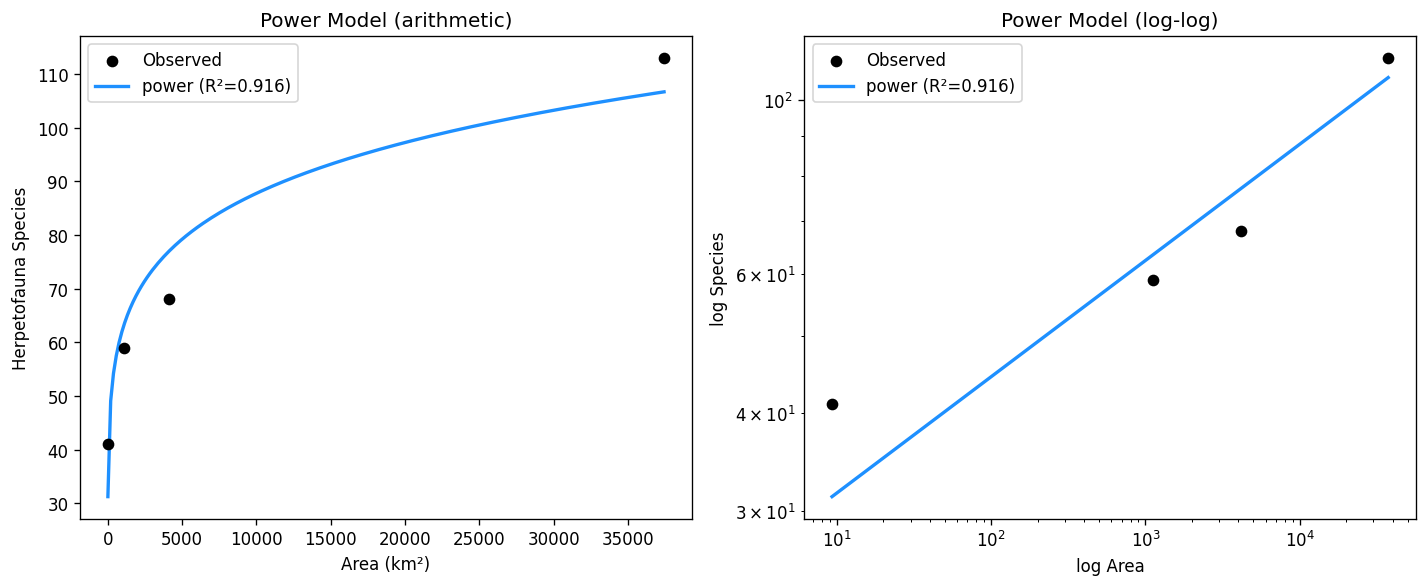

In [4]:
power_fit = sars.sar_power(data_herpetofauna)

print(f"Herpetofauna {power_fit}")
print(f"\nParameters: {power_fit.params}")
print(f"R²: {power_fit.r_squared:.4f}")
print(f"AICc: {power_fit.aicc:.2f}\n")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sars.plot_fit(power_fit, log=False, ax=axes[0])
axes[0].set_title("Power Model (arithmetic)")
axes[0].set_xlabel("Area (km²)")
axes[0].set_ylabel("Herpetofauna Species")

sars.plot_fit(power_fit, log=True, ax=axes[1])
axes[1].set_title("Power Model (log-log)")
axes[1].set_xlabel("log Area")
axes[1].set_ylabel("log Species")

plt.tight_layout()
plt.show()


## Amphibian Power-Law SAR (S = cA^z)

Amphibian SARFit(model='power', c=12.2827  z=0.1616, R²=0.9849, AICc=inf)

Parameters: {'c': np.float64(12.282728396934932), 'z': np.float64(0.16155892187835752)}
R²: 0.9849
AICc: inf



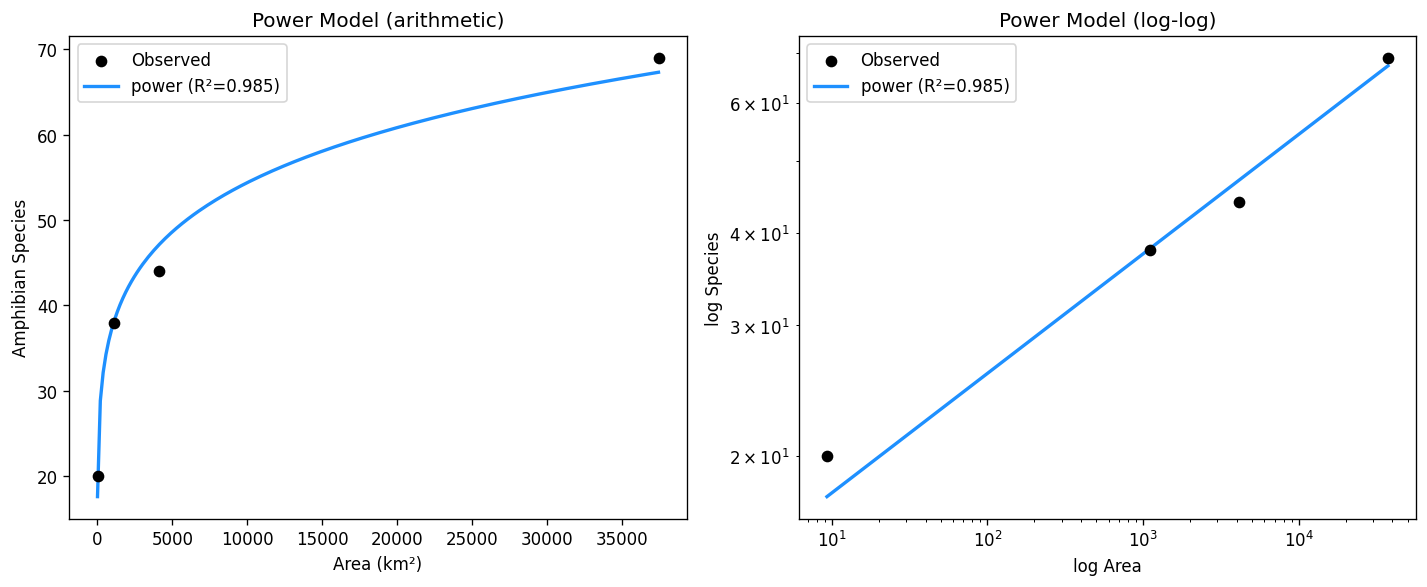

In [5]:
power_fit = sars.sar_power(data_amphibians)

print(f"Amphibian {power_fit}")
print(f"\nParameters: {power_fit.params}")
print(f"R²: {power_fit.r_squared:.4f}")
print(f"AICc: {power_fit.aicc:.2f}\n")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sars.plot_fit(power_fit, log=False, ax=axes[0])
axes[0].set_title("Power Model (arithmetic)")
axes[0].set_xlabel("Area (km²)")
axes[0].set_ylabel("Amphibian Species")

sars.plot_fit(power_fit, log=True, ax=axes[1])
axes[1].set_title("Power Model (log-log)")
axes[1].set_xlabel("log Area")
axes[1].set_ylabel("log Species")

plt.tight_layout()
plt.show()

Reptile SARFit(model='power', c=10.9570  z=0.1205, R²=0.6619, AICc=inf)

Parameters: {'c': np.float64(10.957036762348634), 'z': np.float64(0.12050487220772282)}
R²: 0.6619
AICc: inf



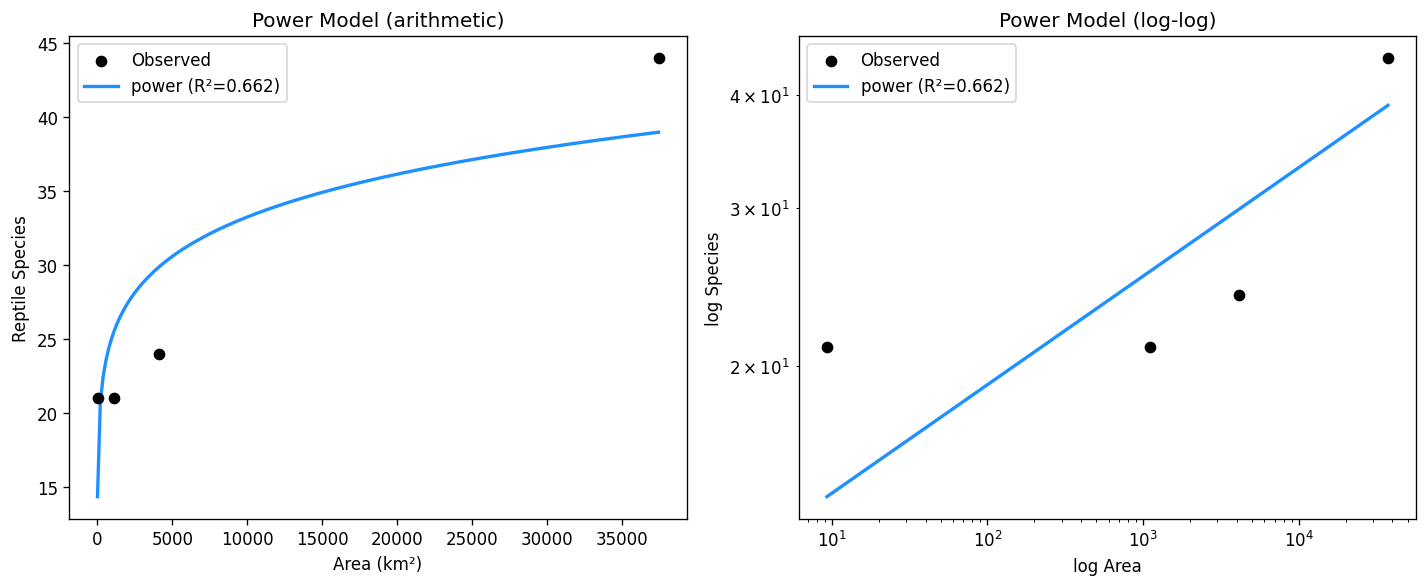

In [6]:
power_fit = sars.sar_power(data_reptiles)

print(f"Reptile {power_fit}")
print(f"\nParameters: {power_fit.params}")
print(f"R²: {power_fit.r_squared:.4f}")
print(f"AICc: {power_fit.aicc:.2f}\n")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sars.plot_fit(power_fit, log=False, ax=axes[0])
axes[0].set_title("Power Model (arithmetic)")
axes[0].set_xlabel("Area (km²)")
axes[0].set_ylabel("Reptile Species")

sars.plot_fit(power_fit, log=True, ax=axes[1])
axes[1].set_title("Power Model (log-log)")
axes[1].set_xlabel("log Area")
axes[1].set_ylabel("log Species")

plt.tight_layout()
plt.show()

# Herpetofauna Multi-Model Comparison

Fit all supported SAR models and rank by AICs.

In [ ]:
multi = sars.sar_multi(data_herpetofauna)
print(multi)
multi.summary

/home/john/repos/scp-sar-ar/.venv/lib/python3.12/site-packages/sars/_models.py:324: RuntimeWarning: overflow encountered in power
  return c * a ** (z1 * a**z2)
/home/john/repos/scp-sar-ar/.venv/lib/python3.12/site-packages/scipy/optimize/_lsq/least_squares.py:965: RuntimeWarning: overflow encountered in dot
  initial_cost = 0.5 * np.dot(f0, f0)
/home/john/repos/scp-sar-ar/.venv/lib/python3.12/site-packages/scipy/optimize/_lsq/trf.py:224: RuntimeWarning: overflow encountered in dot
  cost = 0.5 * np.dot(f, f)
/home/john/repos/scp-sar-ar/.venv/lib/python3.12/site-packages/scipy/optimize/_lsq/common.py:595: RuntimeWarning: overflow encountered in dot
  return J.T.dot(f)
/home/john/repos/scp-sar-ar/.venv/lib/python3.12/site-packages/scipy/optimize/_lsq/trf.py:353: RuntimeWarning: overflow encountered in dot
  cost_new = 0.5 * np.dot(f_new, f_new)
/home/john/repos/scp-sar-ar/.venv/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2767: RuntimeWarning: overflow encountered in dot
  sqnor

,model,R2,AIC,AICc,BIC,delta_AICc,weight,shape,asymptote
0,power,0.916192,33.659954,inf,31.818837,NaN,0.0,convex,NaN
1,powerR,0.997662,21.343804,inf,18.888981,NaN,0.0,convex,NaN
2,epm1,0.996579,22.865139,inf,20.410316,NaN,0.0,convex,NaN
3,epm2,0.998484,19.609055,inf,17.154232,NaN,0.0,convex,NaN
4,p1,0.916192,35.659954,inf,33.205131,NaN,0.0,convex,NaN
5,p2,0.916192,35.659954,inf,33.205131,NaN,0.0,convex,NaN
6,loga,0.792958,37.277513,inf,35.436396,NaN,0.0,convex,NaN
7,koba,0.793606,37.264979,inf,35.423862,NaN,0.0,convex,NaN
8,mmf,0.916185,35.660290,inf,33.205467,NaN,0.0,sigmoid,999999.999998
9,monod,0.415964,41.425675,inf,39.584559,NaN,0.0,convex,80.479797


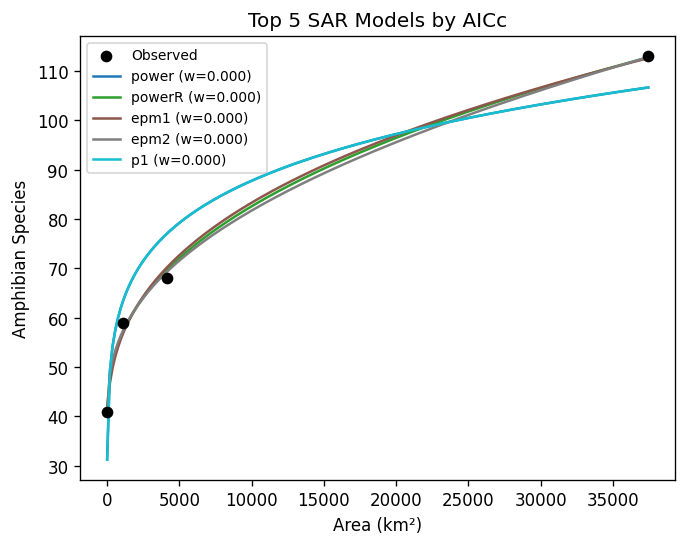

In [8]:
sars.plot_multi(multi, top_n=5)
plt.title("Top 5 SAR Models by AICc")
plt.xlabel("Area (km²)")
plt.ylabel("Amphibian Species")
plt.show()

# Amphibians vs. Reptiles Power (move up)

In [9]:
amp_power = sars.sar_power(data_amphibians)
rep_power = sars.sar_power(data_reptiles)

print("Amphibians:       ", amp_power.params, f"  R²={amp_power.r_squared:.4f}")
print("Reptiles: ", rep_power.params, f"  R²={rep_power.r_squared:.4f}")

Amphibians:        {'c': np.float64(12.282728396934932), 'z': np.float64(0.16155892187835752)}   R²=0.9849
Reptiles:  {'c': np.float64(10.957036762348634), 'z': np.float64(0.12050487220772282)}   R²=0.6619


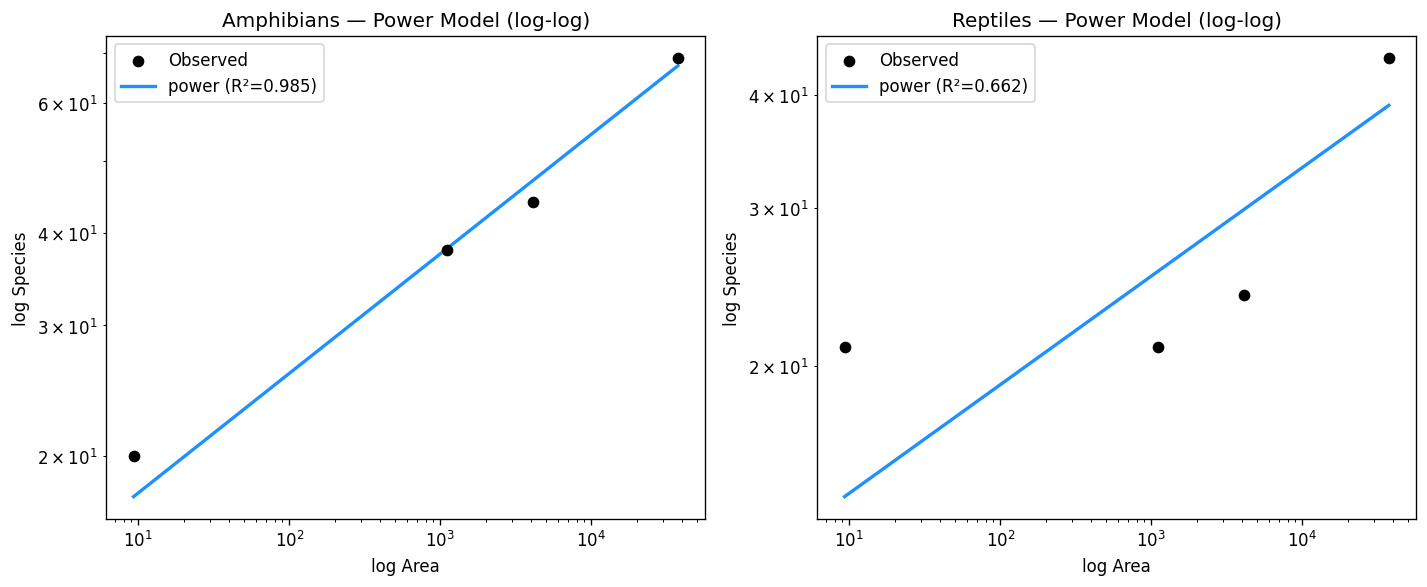

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sars.plot_fit(amp_power, log=True, ax=axes[0])
axes[0].set_title("Amphibians — Power Model (log-log)")
axes[0].set_xlabel("log Area")
axes[0].set_ylabel("log Species")

sars.plot_fit(rep_power, log=True, ax=axes[1])
axes[1].set_title("Reptiles — Power Model (log-log)")
axes[1].set_xlabel("log Area")
axes[1].set_ylabel("log Species")

plt.tight_layout()
plt.show()

# Multi-Model Comparison Amphibians vs. Reptiles

/home/john/repos/scp-sar-ar/.venv/lib/python3.12/site-packages/sars/_models.py:461: RuntimeWarning: overflow encountered in exp
  func=lambda a, d, z, c: d * np.exp(-np.exp(-z * (a - c))),


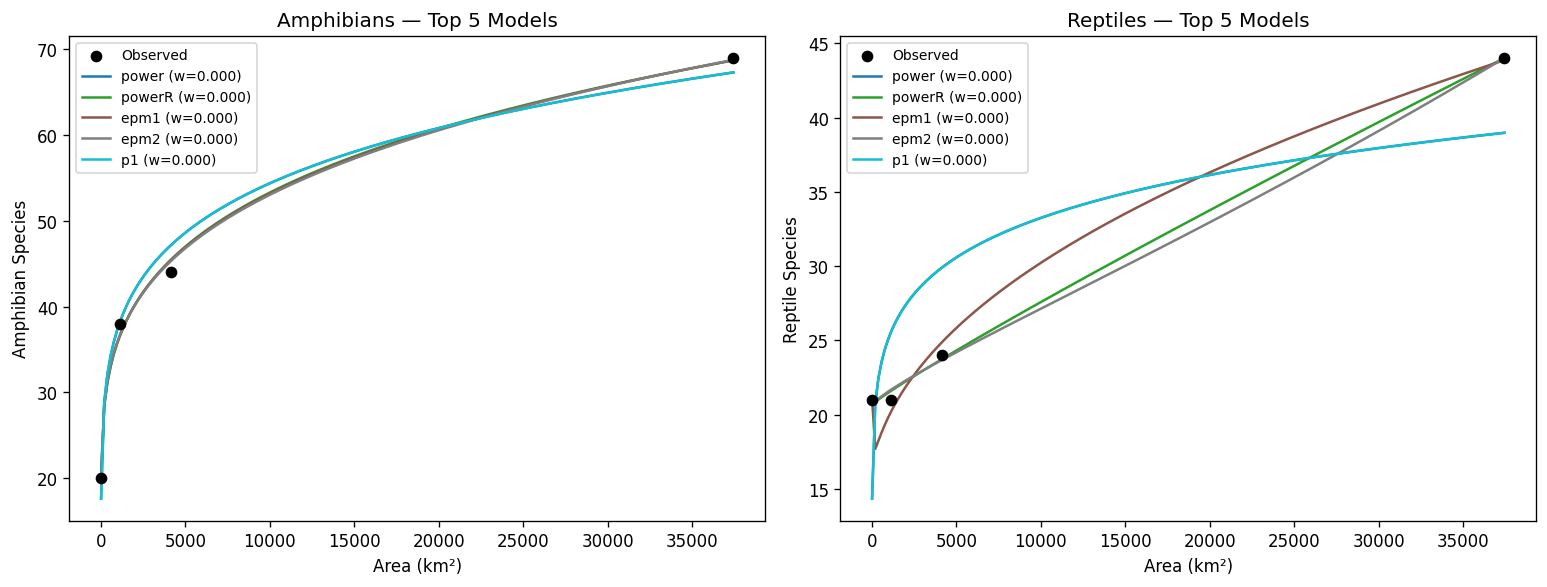

In [12]:
amp_multi = sars.sar_multi(data_amphibians)
rep_multi = sars.sar_multi(data_reptiles)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sars.plot_multi(amp_multi, top_n=5, ax=axes[0])
axes[0].set_title("Amphibians — Top 5 Models")
axes[0].set_xlabel("Area (km²)")
axes[0].set_ylabel("Amphibian Species")

sars.plot_multi(rep_multi, top_n=5, ax=axes[1])
axes[1].set_title("Reptiles — Top 5 Models")
axes[1].set_xlabel("Area (km²)")
axes[1].set_ylabel("Reptile Species")

plt.tight_layout()
plt.show()

In [13]:
print("=== Amphibians — Top 5 ===")
display(amp_multi.summary.head())
print("\n=== Reptiles — Top 5 ===")
display(rep_multi.summary.head())

=== Amphibians — Top 5 ===


,model,R2,AIC,AICc,BIC,delta_AICc,weight,shape,asymptote
0,power,0.984921,23.489935,inf,21.648818,NaN,0.0,convex,NaN
1,powerR,0.996382,19.780544,inf,17.325722,NaN,0.0,convex,NaN
2,epm1,0.996664,19.456175,inf,17.001352,NaN,0.0,convex,NaN
3,epm2,0.996965,19.077501,inf,16.622679,NaN,0.0,convex,NaN
4,p1,0.984921,25.489935,inf,23.035112,NaN,0.0,convex,NaN



=== Reptiles — Top 5 ===


,model,R2,AIC,AICc,BIC,delta_AICc,weight,shape,asymptote
0,power,0.661880,31.112099,inf,29.270982,NaN,0.0,convex,NaN
1,powerR,0.998608,11.142668,inf,8.687846,NaN,0.0,convex,NaN
2,epm1,0.995972,15.391081,inf,12.936259,NaN,0.0,convex,NaN
3,epm2,0.998221,12.121918,inf,9.667095,NaN,0.0,convex,NaN
4,p1,0.661880,33.112099,inf,30.657276,NaN,0.0,convex,NaN
